# EEP 153 Project 3
## Mali: Food Demand by Wealth Quartile

This notebook loads Mali household and food expenditure data, aligns the sample to 2021-22, estimates a food demand system, and compares bottom- versus top-wealth-quartile households in terms of household composition and food spending.

## 1. Load packages

In [2]:
%pip uninstall -y cfe
%pip install --upgrade CFEDemands

Found existing installation: cfe 0.0.22
Uninstalling cfe-0.0.22:
  Successfully uninstalled cfe-0.0.22
Note: you may need to restart the kernel to use updated packages.
  Using cached cfedemands-0.8.2-py3-none-any.whl.metadata (2.3 kB)
  Using cached consumerdemands-0.5.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
Using cached cfedemands-0.8.2-py3-none-any.whl (98 kB)
Using cached consumerdemands-0.5.0-py3-none-any.whl (14 kB)
Using cached fsspec-2026.3.0-py3-none-any.whl (202 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [CFEDemands]
Note: you may need to restart the kernel to use updated packages.


In [1]:

import pandas as pd
import numpy as np
import cfe
import matplotlib.pyplot as plt

Regression = cfe.Regression

## 2. Load raw data

In [3]:
x_raw = pd.read_csv("Mali - Food Expenditures (2021-22).csv")
d_raw = pd.read_csv("Mali - Household Characteristics.csv")

print(x_raw.head())
print(d_raw.head())

         t       m        i                   j  expenditure
0  2021-22  Bamako  1015001                 Ail          600
1  2021-22  Bamako  1015001           Aubergine           50
2  2021-22  Bamako  1015001        Banane douce          300
3  2021-22  Bamako  1015001  Beignets, galettes          300
4  2021-22  Bamako  1015001              Beurre         1100
         t      m     i  F 00-03  F 04-08  F 09-13  F 14-18  F 19-30  F 31-50  \
0  2017-18  Kayes  1001      NaN      2.0      1.0      NaN      2.0      NaN   
1  2017-18  Kayes  1002      3.0      NaN      NaN      2.0      2.0      1.0   
2  2017-18  Kayes  1003      NaN      3.0      4.0      4.0      1.0      2.0   
3  2017-18  Kayes  1004      6.0      3.0      5.0      6.0      5.0      4.0   
4  2017-18  Kayes  1005      1.0      3.0      1.0      4.0      2.0      3.0   

   F 51+  M 00-03  M 04-08  M 09-13  M 14-18  M 19-30  M 31-50  M 51+  M NA  \
0    NaN      1.0      2.0      NaN      NaN      NaN      1.0    Na

## 3. Restrict household data to 2021-22

In [4]:
print("x years:", x_raw["t"].unique())
print("d years:", d_raw["t"].unique())

d_raw = d_raw[d_raw["t"] == "2021-22"].copy()

print("x years after check:", x_raw["t"].unique())
print("d years after filter:", d_raw["t"].unique())

x years: ['2021-22']
d years: ['2017-18' '2021-22' '2018-19' '2014-15']
x years after check: ['2021-22']
d years after filter: ['2021-22']


## 4. Prepare food expenditures and household characteristics

In [5]:
if "expenditure" in x_raw.columns and "Expenditure" not in x_raw.columns:
    x_raw = x_raw.rename(columns={"expenditure": "Expenditure"})

In [6]:
x = x_raw.pivot_table(
    index=["i", "t", "m"],
    columns="j",
    values="Expenditure",
    aggfunc="sum"
)

x = x.replace(0, np.nan)
x_wide = x.copy()
y = np.log(x)

print(y.head())

j                   Ail  Ananas  Arachide  Attiéke  Aubergine  Autres agrumes  \
i    t       m                                                                  
1001 2021-22 Kayes  NaN     NaN       NaN      NaN        NaN             NaN   
1002 2021-22 Kayes  NaN     NaN       NaN      NaN   6.214608             NaN   
1003 2021-22 Kayes  NaN     NaN       NaN      NaN   5.298317             NaN   
1004 2021-22 Kayes  NaN     NaN       NaN      NaN   5.010635             NaN   
1005 2021-22 Kayes  NaN     NaN       NaN      NaN        NaN             NaN   

j                   Autres farines de céréales  Autres fruits  \
i    t       m                                                  
1001 2021-22 Kayes                         NaN            NaN   
1002 2021-22 Kayes                         NaN            NaN   
1003 2021-22 Kayes                         NaN            NaN   
1004 2021-22 Kayes                         NaN            NaN   
1005 2021-22 Kayes                        

In [7]:
d = d_raw.copy()
d.columns.name = "k"
d = d.set_index(["i", "t", "m"])
d = d.fillna(0)

print(d.head())

k                   F 00-03  F 04-08  F 09-13  F 14-18  F 19-30  F 31-50  \
i    t       m                                                             
1001 2021-22 Kayes      0.0      0.0      0.0      0.0      0.0      0.0   
1002 2021-22 Kayes      0.0      0.0      1.0      0.0      0.0      2.0   
1003 2021-22 Kayes      0.0      0.0      0.0      1.0      0.0      1.0   
1004 2021-22 Kayes      0.0      0.0      1.0      0.0      1.0      1.0   
1005 2021-22 Kayes      0.0      1.0      1.0      3.0      0.0      0.0   

k                   F 51+  M 00-03  M 04-08  M 09-13  M 14-18  M 19-30  \
i    t       m                                                           
1001 2021-22 Kayes    0.0      0.0      0.0      0.0      0.0      0.0   
1002 2021-22 Kayes    0.0      0.0      2.0      2.0      0.0      1.0   
1003 2021-22 Kayes    0.0      0.0      1.0      1.0      0.0      1.0   
1004 2021-22 Kayes    0.0      0.0      2.0      0.0      0.0      0.0   
1005 2021-22 Kayes    2

## 5. Match households across datasets

In [8]:
print("number of food observations:", len(x.index))
print("number of household observations:", len(d.index))
print("number of matching observations:", len(x.index.intersection(d.index)))

number of food observations: 6125
number of household observations: 6143
number of matching observations: 6125


In [9]:
common_index = x.index.intersection(d.index)

x = x.loc[common_index]
x_wide = x_wide.loc[common_index]
y = y.loc[common_index]
d = d.loc[common_index]

print("matched x shape:", x.shape)
print("matched d shape:", d.shape)

matched x shape: (6125, 132)
matched d shape: (6125, 17)


In [10]:
y = y.stack().dropna()
d = d.stack().dropna()

print(y.index.names)
print(d.index.names)

['i', 't', 'm', 'j']
['i', 't', 'm', 'k']


## 6. Estimate the food demand system

In [11]:
result = Regression(y=y, d=d)
pred = result.predicted_expenditures()

In [12]:
pred.head()

i     t        m      j                 
1001  2021-22  Kayes  Ail                    42.788809
                      Arachide              233.728890
                      Aubergine              63.663647
                      Beignets, galettes    130.616494
                      Biscuit               133.295455
dtype: float64

## 7. Construct wealth quartiles

In [13]:
hh_total = x_wide.sum(axis=1).rename("total_food_exp")

wealth_quartile = pd.qcut(
    hh_total,
    4,
    labels=["Bottom quartile", "Q2", "Q3", "Top quartile"]
)

wealth_df = hh_total.to_frame()
wealth_df["wealth_quartile"] = wealth_quartile

wealth_df.head()

,,,total_food_exp,wealth_quartile
i,t,m,,
1001,2021-22,Kayes,4625.0,Bottom quartile
1002,2021-22,Kayes,3200.0,Bottom quartile
1003,2021-22,Kayes,3700.0,Bottom quartile
1004,2021-22,Kayes,2500.0,Bottom quartile
1005,2021-22,Kayes,7375.0,Q2


## 8. Build a household-level analysis table

In [14]:
analysis_df = d_raw.copy()
analysis_df = analysis_df.set_index(["i", "t", "m"])
analysis_df = analysis_df.fillna(0)
analysis_df = analysis_df.loc[common_index].copy()

analysis_df["total_food_exp"] = hh_total.loc[common_index]
analysis_df["wealth_quartile"] = wealth_quartile.loc[common_index]

analysis_df.head()

,,,F 00-03,F 04-08,F 09-13,F 14-18,F 19-30,F 31-50,F 51+,M 00-03,M 04-08,M 09-13,M 14-18,M 19-30,M 31-50,M 51+,M NA,log HSize,F NA,total_food_exp,wealth_quartile
i,t,m,,,,,,,,,,,,,,,,,,,
1001,2021-22,Kayes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.693147,0.0,4625.0,Bottom quartile
1002,2021-22,Kayes,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,2.197225,0.0,3200.0,Bottom quartile
1003,2021-22,Kayes,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.791759,0.0,3700.0,Bottom quartile
1004,2021-22,Kayes,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.791759,0.0,2500.0,Bottom quartile
1005,2021-22,Kayes,0.0,1.0,1.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.197225,0.0,7375.0,Q2


## 9. Compare household composition by wealth quartile

In [15]:
analysis_df.groupby("wealth_quartile", observed=False)[[
    "log HSize",
    "F 00-03", "M 00-03",
    "F 04-08", "M 04-08",
    "F 09-13", "M 09-13",
    "F 14-18", "M 14-18"
]].mean()

,log HSize,F 00-03,M 00-03,F 04-08,M 04-08,F 09-13,M 09-13,F 14-18,M 14-18
wealth_quartile,,,,,,,,,
Bottom quartile,1.737215,0.362630,0.397786,0.582031,0.608724,0.480469,0.503255,0.263021,0.328125
Q2,1.836053,0.389143,0.419882,0.598430,0.633748,0.488555,0.531066,0.367560,0.371485
Q3,1.854905,0.383007,0.432026,0.562092,0.689542,0.490850,0.525490,0.386928,0.418954
Top quartile,1.871680,0.345098,0.354248,0.628758,0.693464,0.528105,0.588235,0.377124,0.439216


## 10. Create child-burden proxy variables

In [16]:
analysis_df["young_children_0_3"] = analysis_df["F 00-03"] + analysis_df["M 00-03"]

analysis_df["children_0_18"] = (
    analysis_df["F 00-03"] + analysis_df["M 00-03"] +
    analysis_df["F 04-08"] + analysis_df["M 04-08"] +
    analysis_df["F 09-13"] + analysis_df["M 09-13"] +
    analysis_df["F 14-18"] + analysis_df["M 14-18"]
)

analysis_df.groupby("wealth_quartile", observed=False)[[
    "young_children_0_3",
    "children_0_18",
    "log HSize"
]].mean()

,young_children_0_3,children_0_18,log HSize
wealth_quartile,,,
Bottom quartile,0.760417,3.526042,1.737215
Q2,0.809026,3.799869,1.836053
Q3,0.815033,3.888889,1.854905
Top quartile,0.699346,3.954248,1.871680


## 11. Compare food expenditures by wealth quartile

In [17]:
tmp = x_wide.loc[common_index].copy()
tmp["wealth_quartile"] = wealth_quartile.loc[common_index]

food_means = tmp.groupby("wealth_quartile", observed=False).mean(numeric_only=True).T

bottom_top = food_means[["Bottom quartile", "Top quartile"]].copy()
bottom_top["difference"] = bottom_top["Top quartile"] - bottom_top["Bottom quartile"]

bottom_top.sort_values("difference", ascending=False).head(20)

wealth_quartile,Bottom quartile,Top quartile,difference
j,,,
Riz local Gambiaka,752.477064,20985.544676,20233.067611
Riz brisé importé,842.717391,18981.877256,18139.159865
Mil,754.207921,17122.583893,16368.375972
Riz importé parfumé,858.888889,16729.976852,15871.087963
Sorgho,442.500000,13971.153846,13528.653846
Maïs,523.809524,13098.721591,12574.912067
Riz local fumé,898.728814,12401.676829,11502.948016
Autres viandes,750.000000,4833.333333,4083.333333
Gibiers,650.000000,4500.000000,3850.000000


## 12. Visualize the largest expenditure gaps

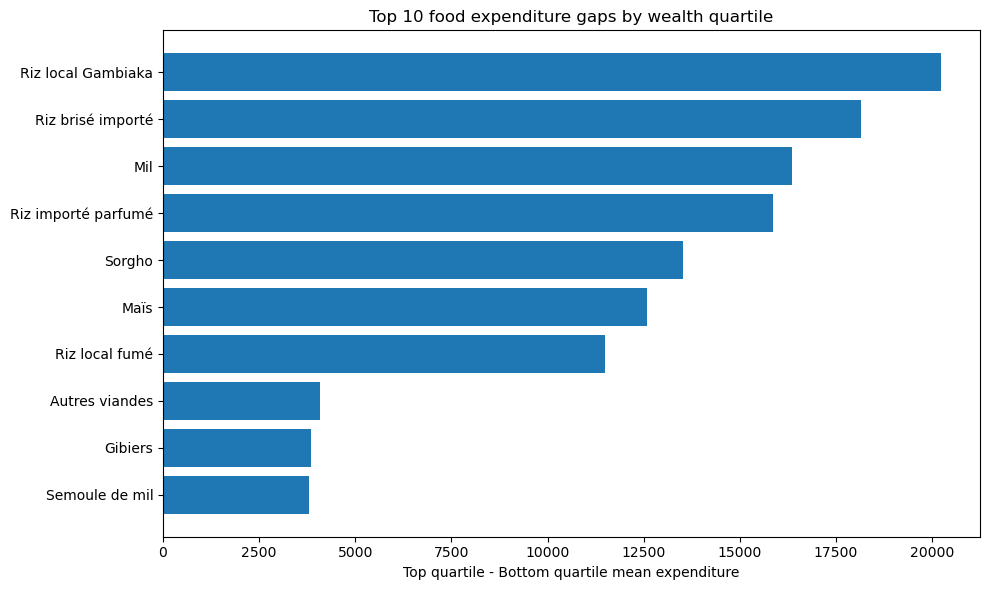

In [18]:
top10 = bottom_top.sort_values("difference", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10.index, top10["difference"])
plt.xlabel("Top quartile - Bottom quartile mean expenditure")
plt.title("Top 10 food expenditure gaps by wealth quartile")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 12A. Convert selected food expenditures into estimated quantities and nutrients

This section uses the group’s food nutrient/price lookup sheet for selected foods.

Important assumption:
- Nutrient values are listed per 100g.
- The row "Price, avg across regions" is treated as an average price per kilogram.

So the quantity conversion is:

quantity (kg) = expenditure / price

Then nutrient totals are computed as:

(quantity in grams / 100) × nutrient value per 100g

In [19]:
nutri_raw = pd.read_csv("Mali Food nutrients and prices - Sheet1.csv")

nutri_raw = nutri_raw.rename(columns={
    "French name": "measure",
    "Unnamed: 1": "unit"})

print(nutri_raw.head())
print(nutri_raw.shape)
print(nutri_raw.columns.tolist())

                            measure  unit  \
0                      English name   NaN   
1                        Sodium, Na    mg   
2  Energy (Atwater General Factors)  kcal   
3                           Protein     g   
4              Fiber, total dietary     g   

                                Riz local Gambiaka  \
0  Local Gambiaka Rice (nutrients from White rice)   
1                                                0   
2                                              359   
3                                             7.04   
4                                              0.1   

                                   Riz brisé importé                   Mil  \
0  \nImported broken rice (nutrients from White r...  millet (whole grain)   
1                                                  0                 < 2.5   
2                                                359                   376   
3                                               7.04                    10   
4             

In [20]:
food_cols = nutri_raw.columns[2:]

price_lookup = (
    nutri_raw[nutri_raw["measure"] == "Price, avg across regions"][food_cols]
    .T
    .reset_index()
)

price_lookup.columns = ["food", "price_avg"]
price_lookup["price_avg"] = pd.to_numeric(price_lookup["price_avg"], errors="coerce")

nutrient_rows = nutri_raw[
    nutri_raw["measure"].notna() &
    ~nutri_raw["measure"].isin([
        "English name",
        "**Per 100g",
        "Price, avg across regions"
    ])
].copy()

nutrient_long = nutrient_rows.melt(
    id_vars=["measure", "unit"],
    value_vars=food_cols,
    var_name="food",
    value_name="amount_per_100g"
)

nutrient_long["amount_per_100g"] = pd.to_numeric(
    nutrient_long["amount_per_100g"],
    errors="coerce"
)

print(price_lookup.head())
print(nutrient_long.head())

                  food  price_avg
0   Riz local Gambiaka    1860.51
1    Riz brisé importé    1683.02
2                  Mil    1063.25
3  Riz importé parfumé    1774.58
4               Sorgho     709.23
                            measure  unit                food  amount_per_100g
0                        Sodium, Na    mg  Riz local Gambiaka             0.00
1  Energy (Atwater General Factors)  kcal  Riz local Gambiaka           359.00
2                           Protein     g  Riz local Gambiaka             7.04
3              Fiber, total dietary     g  Riz local Gambiaka             0.10
4                       Folate, DFE    µg  Riz local Gambiaka              NaN


In [21]:
foods_in_lookup = [food for food in price_lookup["food"] if food in x_wide.columns]

print("Number of foods in lookup that match x_wide:", len(foods_in_lookup))
print(foods_in_lookup)

Number of foods in lookup that match x_wide: 20
['Riz local Gambiaka', 'Riz brisé importé', 'Mil', 'Riz importé parfumé', 'Sorgho', 'Maïs', 'Riz local fumé', 'Autres viandes', 'Gibiers', 'Semoule de mil', 'Poulet sur pied', 'Farine de blé', 'Huile de coton', 'Farine de mil', 'Viande de mouton', 'Huile de palme', 'Semoule de mais', 'Viande de chèvre', 'Sucre poudre', "Huile d'arachide"]


In [22]:
price_series = (
    price_lookup.set_index("food")
    .loc[foods_in_lookup, "price_avg"]
)

food_exp_lookup = x_wide[foods_in_lookup].fillna(0).copy()

# Assumes price_avg is price per kilogram
quantity_kg = food_exp_lookup.div(price_series, axis=1)
quantity_g = quantity_kg * 1000

print(quantity_g.head())

j                   Riz local Gambiaka  Riz brisé importé  Mil  \
i    t       m                                                   
1001 2021-22 Kayes                 0.0                0.0  0.0   
1002 2021-22 Kayes                 0.0                0.0  0.0   
1003 2021-22 Kayes                 0.0                0.0  0.0   
1004 2021-22 Kayes                 0.0                0.0  0.0   
1005 2021-22 Kayes                 0.0                0.0  0.0   

j                   Riz importé parfumé  Sorgho  Maïs  Riz local fumé  \
i    t       m                                                          
1001 2021-22 Kayes                  0.0     0.0   0.0             0.0   
1002 2021-22 Kayes                  0.0     0.0   0.0             0.0   
1003 2021-22 Kayes                  0.0     0.0   0.0             0.0   
1004 2021-22 Kayes                  0.0     0.0   0.0             0.0   
1005 2021-22 Kayes                  0.0     0.0   0.0             0.0   

j                   Autre

In [23]:
selected_nutrients = [
    "Energy (Atwater General Factors)",
    "Protein",
    "Iron, Fe",
    "Zinc, Zn",
    "Vitamin A, RAE"
]

nutrient_pivot = (
    nutrient_long[nutrient_long["measure"].isin(selected_nutrients)]
    .pivot_table(
        index="food",
        columns="measure",
        values="amount_per_100g",
        aggfunc="first"
    )
    .reindex(foods_in_lookup)
    .fillna(0)
)

household_nutrients = pd.DataFrame(index=quantity_g.index)

for nutrient in selected_nutrients:
    total = pd.Series(0.0, index=quantity_g.index)

    for food in foods_in_lookup:
        nutrient_per_100g = nutrient_pivot.loc[food, nutrient]
        total = total + (quantity_g[food] / 100) * nutrient_per_100g

    household_nutrients[nutrient] = total

household_nutrients.head()

,,,Energy (Atwater General Factors),Protein,"Iron, Fe","Zinc, Zn","Vitamin A, RAE"
i,t,m,,,,,
1001,2021-22,Kayes,1915.557095,0.0,0.247488,0.049498,0.0
1002,2021-22,Kayes,2131.702565,0.0,0.024114,0.000000,0.0
1003,2021-22,Kayes,11433.695774,0.0,0.388021,0.129340,0.0
1004,2021-22,Kayes,3811.231925,0.0,0.129340,0.043113,0.0
1005,2021-22,Kayes,0.000000,0.0,0.000000,0.000000,0.0


In [24]:
analysis_nutrients = analysis_df.join(household_nutrients, how="left")

nutrient_by_quartile = analysis_nutrients.groupby(
    "wealth_quartile",
    observed=False
)[selected_nutrients].mean()

nutrient_by_quartile

,Energy (Atwater General Factors),Protein,"Iron, Fe","Zinc, Zn","Vitamin A, RAE"
wealth_quartile,,,,,
Bottom quartile,4373.044203,33.876785,4.283534,6.667994,0.070147
Q2,10175.000297,100.395577,13.287260,19.279604,1.889423
Q3,32884.447725,494.145729,47.045968,95.461748,5.357349
Top quartile,112548.875542,1989.348975,337.710341,405.341711,9.810656


In [25]:
bottom_top_nutrients = nutrient_by_quartile.loc[
    ["Bottom quartile", "Top quartile"]
].T.copy()

bottom_top_nutrients["difference"] = (
    bottom_top_nutrients["Top quartile"] -
    bottom_top_nutrients["Bottom quartile"]
)

bottom_top_nutrients

wealth_quartile,Bottom quartile,Top quartile,difference
Energy (Atwater General Factors),4373.044203,112548.875542,108175.831339
Protein,33.876785,1989.348975,1955.472190
"Iron, Fe",4.283534,337.710341,333.426806
"Zinc, Zn",6.667994,405.341711,398.673716
"Vitamin A, RAE",0.070147,9.810656,9.740509


In [26]:
analysis_nutrients.groupby("wealth_quartile", observed=False)[[
    "young_children_0_3",
    "children_0_18",
    "Energy (Atwater General Factors)",
    "Protein",
    "Iron, Fe",
    "Zinc, Zn"
]].mean()

,young_children_0_3,children_0_18,Energy (Atwater General Factors),Protein,"Iron, Fe","Zinc, Zn"
wealth_quartile,,,,,,
Bottom quartile,0.760417,3.526042,4373.044203,33.876785,4.283534,6.667994
Q2,0.809026,3.799869,10175.000297,100.395577,13.287260,19.279604
Q3,0.815033,3.888889,32884.447725,494.145729,47.045968,95.461748
Top quartile,0.699346,3.954248,112548.875542,1989.348975,337.710341,405.341711


## 13. Key findings so far

- The analysis compares bottom versus top wealth quartile households in Mali using 2021-22 food expenditure and household characteristics data.
- Top quartile households appear slightly larger on average than bottom quartile households.
- Top quartile households have more children age 0-18 on average, but not more children age 0-3.
- This supports a cautious framing around household composition and child burden rather than direct fertility.
- Top quartile households also spend substantially more in absolute terms on major staples and some higher-value foods.